In [41]:
import sys
import os
sys.path.append(os.path.abspath('../..'))


# from scan_engine.status_fields_config_24summ import STATUS_FIELDS_CONFIG
from status_fields_config_oct3v1_brws_250525 import STATUS_FIELDS_CONFIG

from utlis.scan_engine_utlis.scan_eng_big_utlis import log_folder_to_parquet_sep

base_folder = "/data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused"
failed_paths_file = "/data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/bad_calib.txt"
force_rescan_rec_files = [
    # ('2023-10-01', '001'),
    # ('2023-10-02', '002'),
    # Add more as needed
]
rescan_threshold_days = 0.000000001 # 7 days, but guess if i mess up i can just change it to automatically rescan all, smile... #0.1

log_folder_to_parquet_sep(base_folder, failed_paths_file, STATUS_FIELDS_CONFIG,
                            force_rescan_rec_files=force_rescan_rec_files,
                            rescan_threshold_days=rescan_threshold_days)


Log for 0single5_group5_ saved at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5_/folder_log.parquet
Log for 0single5_group5 saved at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5/folder_log.parquet
Log for 0single5_group5_3 saved at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5_3/folder_log.parquet
Log for extrinsics saved at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03_17_00/extrinsics/folder_log.parquet
Log for 0single5_group3 saved at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_17/0single5_group3/folder_log.parquet
Log for 0single4_group4 saved at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_17/0single4_group4/folder_log.parquet
Log for 0single4_group3 saved at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_10/0single4_group3/folder_log.parquet
Log for 0single5_group4 s

In [42]:
sys.path.append(os.path.abspath('../..'))
from utlis.scan_engine_utlis.scan_engine_utlis import read_all_parquet_files
# base_folder = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1"
all_df = read_all_parquet_files(base_folder)

In [44]:
import pyarrow.compute as pc
from functools import reduce


table = all_df #combined_df
# Filter mir_generate_param == 0 and sync != 3
conditions = [
   # pc.equal(table['mir_generate_param'], '1'),
   pc.equal(table['sync'], '1'),
#    # pc.not_equal(table['sync'], '3'),
   # pc.equal(table['com'], '1'),
   # pc.equal(table['com_vis'], '0'),
   # # pc.equal(table['v1'], '1'),
#    pc.equal(table['dannce'], '0'),
   # pc.equal(table['dannce_vis'], '1'),
   # pc.equal(table['social'], '1'),
   # pc.equal(table['mini_6cam_map'], '1'),
   # pc.equal(table['mini_rec_sync_com'], '1'),
   #mini_rec_sync
   # mini_6cam_map
]

filter_mask = reduce(pc.and_, conditions)



# Apply the filter and print the results
for_com = table.filter(filter_mask)

# Print each row of the filtered table
print(for_com.to_pandas())  # This will display the filtered data in a familiar pandas-like format


   mir_generate_param sync mini_6cam_map dropf_handle com com_vis social  \
0                   1    1             0            0   0       0      1   
1                   1    1             0            0   0       0      1   
2                   1    1             0            0   1       1      1   
3                   1    1             0            0   1       1      1   
4                   1    1             0            0   1       1      1   
5                   1    1             0            0   0       0      1   
6                   1    1             0            0   1       1      1   
7                   1    1             0            0   1       1      1   
8                   1    1             0            0   1       1      1   
9                   1    1             0            0   1       1      1   
10                  1    1             0            0   1       1      1   
11                  1    1             0            0   1       1      1   
12          

In [45]:
# Convert and flatten the ChunkedArray
experiment_paths = for_com["rec_path"].to_pylist()

# Print each path
for path in experiment_paths:
    # Each element is likely a list with one string, e.g., ['/some/path']
    print(path[0] if isinstance(path, list) else path)


/data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single4_group3
/data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single3_group4_1
/data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_17/0single5_group4
/data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_25/0single5_group2
/data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_25/0single4_group5
/data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5_3
/data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_01/0single1_group1
/data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_01/0single5_group5
/data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_01/0single2_group2
/data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_01/0single4_group4
/data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_01/0single3_group3
/data/big_rim/rsync_dcc_sum/minji_socia

In [ ]:
from utlis.exe_engine_utlis.comb_all_exe import sequential_process_and_update_mirgenparam
# out_folder =  True
# out_folder_name = "calib_newintrinsics"
calib_folder_name= "calib_before_newintrinsics"
# calib_folder_name= "calib_14_25_newintrinsics"
sequential_process_and_update_mirgenparam(for_com, base_folder, calib_folder_name)

Found 6 calibration files.
Error opening video file.
mir_generate_param ran successfully.
processed failed. please check /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_17/0single4_group2
Found 0 calibration files.
no calib file found. skipping. calib path of /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03_17_00/calib_before
mir_generate_param ran successfully.
processed failed. please check /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03_17_00/extrinsics


Processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single5_group2


[mov,mp4,m4a,3gp,3g2,mj2 @ 0x61d1c76a3240] moov atom not found


Saved brightness plot to /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single5_group2/videos/6cam_sync.png


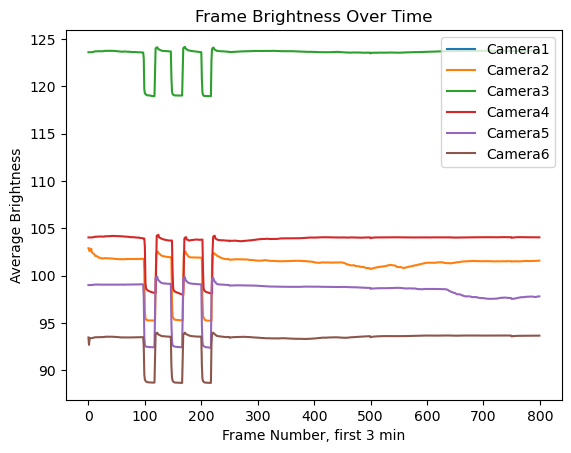

Detected intensity drop frames in /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single5_group2: {'Camera1': [], 'Camera2': [100, 148, 202], 'Camera3': [99, 147, 201], 'Camera4': [101, 149, 203], 'Camera5': [99, 147, 201], 'Camera6': [99, 147, 201]}
Skipping process_calibration_data for /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single5_group2 due to missing drop frames
please mannually process /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single5_group2
Failed processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single5_group2, status set to 3.
Updated Parquet file at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single5_group2/folder_log.parquet with new status.
Processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single3_group4


[mov,mp4,m4a,3gp,3g2,mj2 @ 0x61d1c7e76280] moov atom not found


Saved brightness plot to /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single3_group4/videos/6cam_sync.png


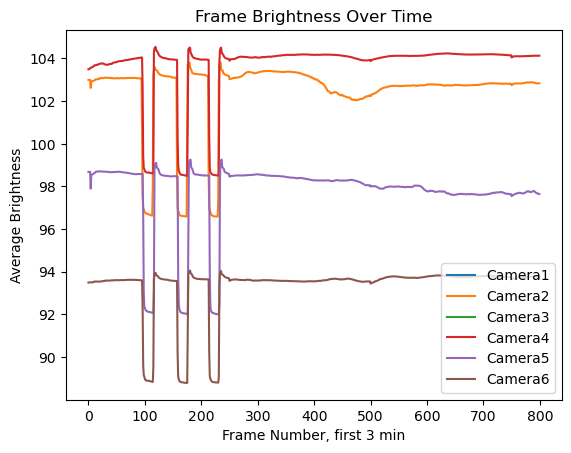

Detected intensity drop frames in /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single3_group4: {'Camera1': [], 'Camera2': [95, 96, 157, 213], 'Camera3': [], 'Camera4': [97, 158, 214], 'Camera5': [98, 159, 215], 'Camera6': [97, 158, 214]}
Skipping process_calibration_data for /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single3_group4 due to missing drop frames
please mannually process /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single3_group4
Failed processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single3_group4, status set to 3.
Updated Parquet file at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single3_group4/folder_log.parquet with new status.
Processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single2_group5
Saved brightness plot to /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0sing

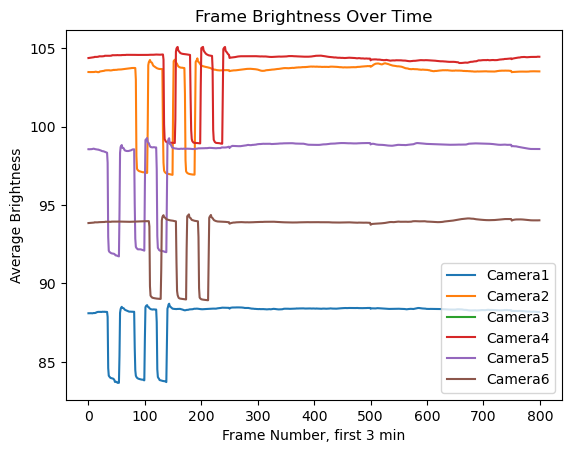

Detected intensity drop frames in /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single2_group5: {'Camera1': [35, 82, 122], 'Camera2': [85, 132, 133, 172], 'Camera3': [], 'Camera4': [134, 181, 182, 221], 'Camera5': [35, 82, 83, 122], 'Camera6': [109, 156, 196]}
Skipping process_calibration_data for /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single2_group5 due to missing drop frames
please mannually process /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single2_group5
Failed processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single2_group5, status set to 3.
Updated Parquet file at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single2_group5/folder_log.parquet with new status.
Processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single5_group2_1
Saved brightness plot to /data/big_rim/rsync_dcc_sum/minji_social_single_grou

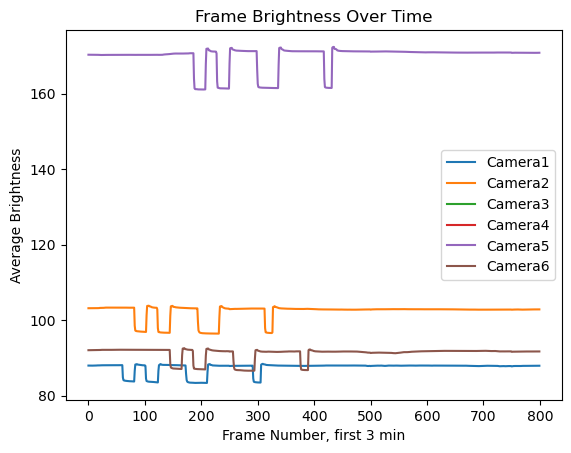

Detected intensity drop frames in /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single5_group2_1: {'Camera1': [61, 102, 173, 292], 'Camera2': [82, 123, 194, 195, 313], 'Camera3': [], 'Camera4': [], 'Camera5': [187, 188, 228, 299, 300, 418, 419], 'Camera6': [145, 186, 257, 376]}
Skipping process_calibration_data for /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single5_group2_1 due to missing drop frames
please mannually process /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single5_group2_1
Failed processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single5_group2_1, status set to 3.
Updated Parquet file at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0single5_group2_1/folder_log.parquet with new status.
Processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0yankun
Saved brightness plot to /data/big_rim/rsync_dcc_sum/minji_so

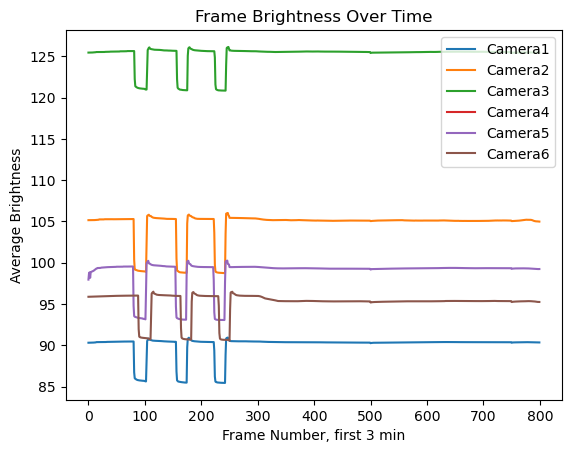

Detected intensity drop frames in /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0yankun: {'Camera1': [81, 156, 224], 'Camera2': [81, 156, 224], 'Camera3': [82, 157, 225], 'Camera4': [], 'Camera5': [80, 155, 223], 'Camera6': [89, 164, 232]}
Skipping process_calibration_data for /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0yankun due to missing drop frames
please mannually process /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0yankun
Failed processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0yankun, status set to 3.
Updated Parquet file at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_03/0yankun/folder_log.parquet with new status.
Processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_17/0single3_group5
Saved brightness plot to /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_17/0single3_group5/videos/6cam_sync.png


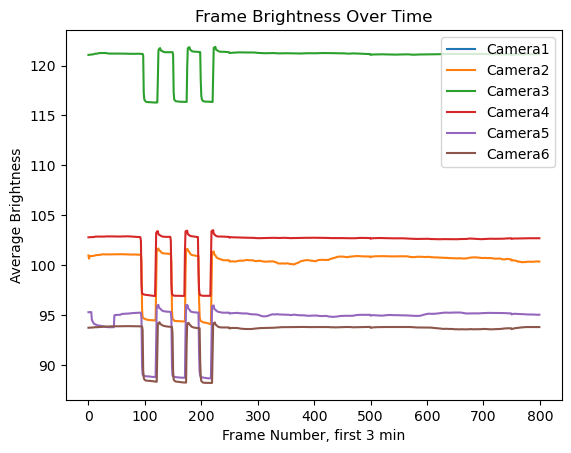

Detected intensity drop frames in /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_17/0single3_group5: {'Camera1': [], 'Camera2': [95, 148, 196], 'Camera3': [98, 151, 199], 'Camera4': [94, 147, 195], 'Camera5': [95, 148, 196], 'Camera6': [97, 150, 198]}
Skipping process_calibration_data for /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_17/0single3_group5 due to missing drop frames
please mannually process /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_17/0single3_group5
Failed processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_17/0single3_group5, status set to 3.
Updated Parquet file at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_07_17/0single3_group5/folder_log.parquet with new status.
Processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5_


[mov,mp4,m4a,3gp,3g2,mj2 @ 0x61d1c803f1c0] moov atom not found


Saved brightness plot to /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5_/videos/6cam_sync.png


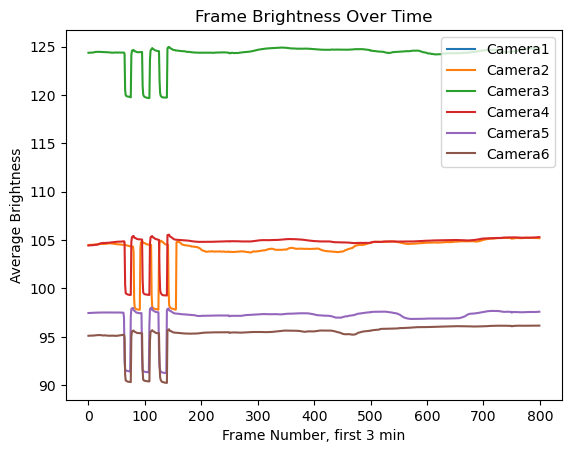

Detected intensity drop frames in /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5_: {'Camera1': [], 'Camera2': [81, 112, 142], 'Camera3': [65, 96, 126], 'Camera4': [65, 96, 126], 'Camera5': [64, 95, 125], 'Camera6': [65, 96, 126]}
Skipping process_calibration_data for /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5_ due to missing drop frames
please mannually process /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5_
Failed processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5_, status set to 3.
Updated Parquet file at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5_/folder_log.parquet with new status.
Processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5


[mov,mp4,m4a,3gp,3g2,mj2 @ 0x61d1c8943c40] moov atom not found


Saved brightness plot to /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5/videos/6cam_sync.png


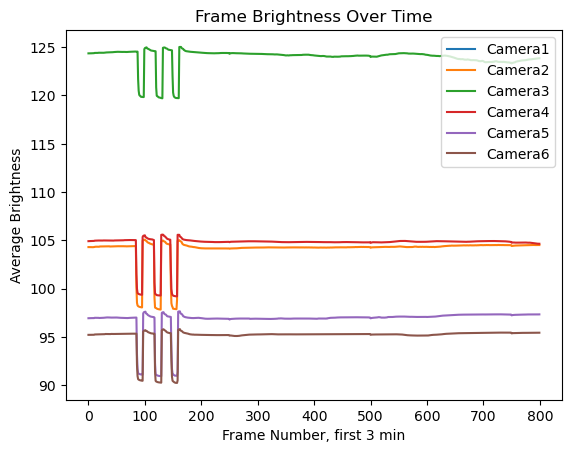

Detected intensity drop frames in /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5: {'Camera1': [], 'Camera2': [85, 117, 146], 'Camera3': [88, 120, 149], 'Camera4': [85, 117, 146, 147], 'Camera5': [86, 118, 147, 148], 'Camera6': [86, 118, 147]}
Skipping process_calibration_data for /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5 due to missing drop frames
please mannually process /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5
Failed processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5, status set to 3.
Updated Parquet file at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_08_04/0single5_group5/folder_log.parquet with new status.
Processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_10/0single3_group2
Saved brightness plot to /data/big_rim/rsync_dcc_sum/minji_social_single_grouphouse

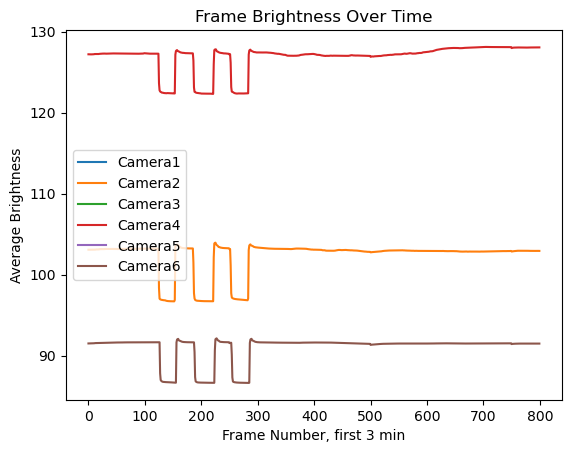

Detected intensity drop frames in /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_10/0single3_group2: {'Camera1': [], 'Camera2': [125, 187, 253], 'Camera3': [], 'Camera4': [125, 187, 253], 'Camera5': [], 'Camera6': [127, 189, 255]}
Skipping process_calibration_data for /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_10/0single3_group2 due to missing drop frames
please mannually process /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_10/0single3_group2
Failed processing: /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_10/0single3_group2, status set to 3.
Updated Parquet file at /data/big_rim/rsync_dcc_sum/minji_social_single_grouphoused/2025_10_10/0single3_group2/folder_log.parquet with new status.


In [40]:
from utlis.exe_engine_utlis.comb_all_exe import sequential_process_and_update_sync
filtered_table = for_com
# sequential_process_and_update_sync(filtered_table, base_folder, max_frames=800) #threshold=2, max_frames=300, min_frame=0
try:
    sequential_process_and_update_sync(filtered_table, base_folder, max_frames=800)
except Exception as e:
    print(f"Skipping due to error: {e}")

In [ ]:
# # social com

# from utlis.exe_engine_utlis.comb_all_exe import dispatch_slurm_jobs
# filtered_table=for_com

# dispatch_slurm_jobs(
#     base_path=base_folder,
#     table=filtered_table,
#     slurm_launch_file="/hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict_social.py",
#     predict_flag="--predict_com",
#     conda_env="sdannce",
#     partition="scavenger-gpu",
#     dry_run=False,
#     max_workers=6,
# )

Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict_social.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single1_group1 --predict_com --partition scavenger-gpu
Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict_social.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single2_group2 --predict_com --partition scavenger-gpu
Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict_social.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single3_group3 --predict_com --partition scavenger-gpu
Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict_social.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_s

In [7]:
# single com

from utlis.exe_engine_utlis.comb_all_exe import dispatch_slurm_jobs
filtered_table = for_com
dispatch_slurm_jobs(
    base_path=base_folder,
    table=filtered_table,
    slurm_launch_file="/hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py",
    predict_flag="--predict_com",
    conda_env="sdannce",
    partition="scavenger-gpu",
    dry_run=False,
    max_workers=6,
)

Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/02mouse_newobj_non_opto --predict_com --partition scavenger-gpu
Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/01mouse_base02 --predict_com --partition scavenger-gpu
Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_14/02mouse_base02 --predict_com --partition scavenger-gpu
Executing: conda run -n sdannce python /hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py --expdir /hpc/group/tdunn/Bryan_Rigs/BigOpenField/lumi_novel_object_recog/2025_10_13/02mouse_base01 --p

In [11]:
# single com vis

from utlis.vis_valid_utlis.com_trag_updated import plot_com_all

# Assume base_folder is defined elsewhere in your script
# base_folder = '/path/to/your/base/folder'
for_com_vis = for_com
records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_com_vis['date_folder'], for_com_vis['rec_file'])
]

# Iterate through the records and process each one sequentially
for record in records:
    base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
    print(base_path)
    plot_com_all(base_path) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False


/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/2025_10_14/02mouse_base02
no com file found for /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/2025_10_14/02mouse_base02
/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/2025_10_14/02mouse_newobj_non_opto
no com file found for /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/2025_10_14/02mouse_newobj_non_opto
/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/2025_10_14/01mouse_base02
no com file found for /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/2025_10_14/01mouse_base02
/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/2025_10_13/01mouse_base01
no com file found for /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/2025_10_13/01mouse_base01
/data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/2025_10_13/02mouse_base01
no com file found for /data/big_rim/rsync_dcc_sum/lumi_novel_object_recog/2025_10_13/02mouse_base01


In [ ]:
# single dannce predict
# below is to exclude the bad com dir mannually, by inserting things in a txt file...


from concurrent.futures import ThreadPoolExecutor
import os

for_dannce = for_com

slurm_launch_file = '/hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py'

def check_expdir(expdir):
    if not os.path.exists(expdir):
        print(f"Skipping: Experiment directory {expdir} does not exist")
        return None  # Return None or skip processing this directory
    return expdir

# Function to create the full expdir path and print the command for dry-run
def run_command(base_path, date_folder, rec_file, partition='scavenger-gpu', dry_run=True):
    expdir_path = os.path.join(base_path, date_folder, rec_file)
    
    # Check if the experiment directory exists before running the command
    if check_expdir(expdir_path) is None:
        return  # Skip this execution if the directory does not exist
    
    command = f"conda run -n sdannce python {slurm_launch_file} --expdir {expdir_path} --predict_dannce --partition {partition}"  # --allow_overwrite removed by default.

    if dry_run:
        print(f"[DRY-RUN] Command: {command}")
    else:
        print(f"Executing command: {command}")
        os.system(command)

# Read the list of relative paths to skip from the .txt file
txt_file = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/25juneon/com_repre.txt"
# '/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1/1_point_com_rerun.txt'  # Update this to the path of your .txt file
rel_paths_to_skip = set()
with open(txt_file, 'r') as f:
    for line in f:
        rel_path = line.strip()
        if rel_path:
            rel_paths_to_skip.add(rel_path)

# print(rel_paths_to_skip)

# Extract relevant data from the filtered PyArrow Table `for_com_vis`
base_path = base_folder  # Ensure base_folder is defined
# base_path = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/24summ"  # Adjust this base path as needed

records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_dannce['date_folder'], for_dannce['rec_file'])
]

# Run in parallel with dry-run enabled for testing
max_concurrent_jobs = 4  # Choose how many jobs to run in parallel

dry_run = False  # Set to False to execute commands

with ThreadPoolExecutor(max_workers=max_concurrent_jobs) as executor:
    futures = []
    futures = []
    for record in records:
        # Create the relative path (date_folder/rec_file)
        rel_path = os.path.join(record['date_folder'], record['rec_file'])
        expdir_path = os.path.join(base_path, rel_path)

        if expdir_path in rel_paths_to_skip:
            print(f"Skipping: {rel_path} is in the skip list")
            continue  # Skip this record if it's in the skip list

        # Submit the job to the executor
        futures.append(
            executor.submit(run_command, base_path, record['date_folder'], record['rec_file'], 'scavenger-gpu', dry_run)
        )


In [ ]:
# #social path:
# from utlis.vis_valid_utlis.com_trace import plot_com_circle_for_path_social

# # path = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single4_group4"
# # plot_com_circle_for_path_social(path)


# for_com_vis = for_com
# records = [
#     {
#         'date_folder': date_folder.as_py(),  # Convert to string using as_py()
#         'rec_file': rec_file.as_py()         # Convert to string using as_py()
#     }
#     for date_folder, rec_file in zip(for_com_vis['date_folder'], for_com_vis['rec_file'])
# ]

# # Iterate through the records and process each one sequentially
# for record in records:
#     base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
#     print(base_path)
#     plot_com_circle_for_path_social(base_path) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False


/hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single4_group4
Primary COM file not found; using fallback: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single4_group4/COM/predict00/com3d0.mat
Saved COM circle plot to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single4_group4/COM/predict00/vis/com_circle.png
/hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single5_group5
Primary COM file not found; using fallback: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single5_group5/COM/predict00/com3d0.mat
Saved COM circle plot to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single5_group5/COM/predict00/vis/com_circle.png
/hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single2_group2
Primary COM file not found; using fallback: 

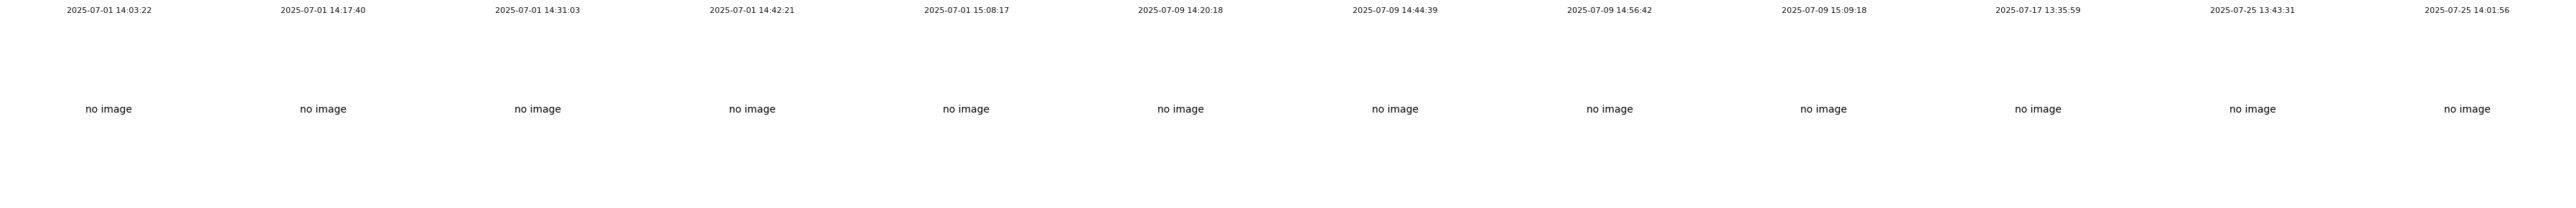

In [ ]:
import os
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.image as mpimg


filtered_table = for_com

# 1. Flatten your rec_paths
rec_paths = filtered_table["rec_path"].to_pylist()
base_paths = [p[0] if isinstance(p, list) else p for p in rec_paths]

# 2. Collect (path, modification time) for each frametimes.mat
sessions = []
for p in base_paths:
    ft = os.path.join(p, "videos", "Camera1", "frametimes.mat")
    if os.path.isfile(ft):
        mtime = os.path.getmtime(ft)
        sessions.append((p, mtime))
    else:
        print(f"Warning: frametimes.mat not found for {p}")

# 3. Sort all sessions by timestamp
sessions.sort(key=lambda x: x[1])

# 4. Plot every session on a single figure
n = len(sessions)
fig, axes = plt.subplots(1, n, figsize=(n * 3, 3))
if n == 1:
    axes = [axes]

for ax, (p, mtime) in zip(axes, sessions):
    img_file = os.path.join(p, "COM/predict00/vis", "com_circle.png")
    if os.path.isfile(img_file):
        img = mpimg.imread(img_file)
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, "no image", ha="center", va="center")
    ts = datetime.fromtimestamp(mtime).strftime("%Y-%m-%d %H:%M:%S")
    ax.set_title(ts, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [10]:
# social com vis

# from utlis.vis_valid_utlis.com_trag_updated import plot_com_all
from utlis.vis_valid_utlis.scom_traga_utlis import plot_com_all_social

# Assume base_folder is defined elsewhere in your script
# base_folder = '/path/to/your/base/folder'
for_com_vis = filtered_table
records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_com_vis['date_folder'], for_com_vis['rec_file'])
]

# Iterate through the records and process each one sequentially
for record in records:
    base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
    print(base_path)
    plot_com_all_social(base_path,perform_generate_com_video=True) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False


In [ ]:
# single dannce valid


from useful_files.sophie_check_dannce_mir_modif import dannce_valid

for_dannce_vis = filtered_table


records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_dannce_vis['date_folder'], for_dannce_vis['rec_file'])
]

# Iterate through the records and process each one sequentially
# for record in records:
#     base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
#     print(base_path)
#     try:
#         dannce_valid(base_path) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False
#     except Exception as e:
#         print(f" An error occurred while processing {base_path}: {e}")
#         # Skip to the next record if an error occurs
#         continue

# #trying for parallel processing again:
from concurrent.futures import ProcessPoolExecutor, as_completed

def process_record(record):
    base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
    print(base_path)
    try:
        dannce_valid(base_path)
    except Exception as e:
        print(f"An error occurred while processing {base_path}: {e}")
        # Skip to the next record if an error occurs
        pass

with ProcessPoolExecutor() as executor:
    futures = [executor.submit(process_record, record) for record in records]
    for future in as_completed(futures):
        pass  # You can retrieve results or handle exceptions here if needed
